In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("crime_train.csv")
df.head(3)

,Unnamed: 0,Num,case_filed,city,area,crime_description,age,sex,weapon,domain,police_department,closed
0,19794,19795,04-04-2022 18:00,Mumbai,307,VEHICLE - STOLEN,63.0,X,Poison,Violent Crime,12.0,No
1,13762,13763,07-27-2021 10:00,Surat,504,ROBBERY,57.0,F,Explosives,Violent Crime,3.0,No
2,30311,30312,06-16-2023 23:00,Thane,493,ASSAULT,33.0,F,Firearm,Violent Crime,18.0,No


## Preprocessing

In [3]:
df = df.dropna()

In [4]:
# Now removing - [Unnamed: 0, Num and case_filed] Columns as they are of no use
df = df.drop(['Unnamed: 0', 'Num', 'case_filed'], axis=1)
df.head(2)

,city,area,crime_description,age,sex,weapon,domain,police_department,closed
0,Mumbai,307,VEHICLE - STOLEN,63.0,X,Poison,Violent Crime,12.0,No
1,Surat,504,ROBBERY,57.0,F,Explosives,Violent Crime,3.0,No


In [5]:
df.isnull().sum()   #so all NaN values are removed(dropped)

city                 0
area                 0
crime_description    0
age                  0
sex                  0
weapon               0
domain               0
police_department    0
closed               0
dtype: int64

In [6]:
df['closed']=df['closed'].map({'Yes':1,'No':0})

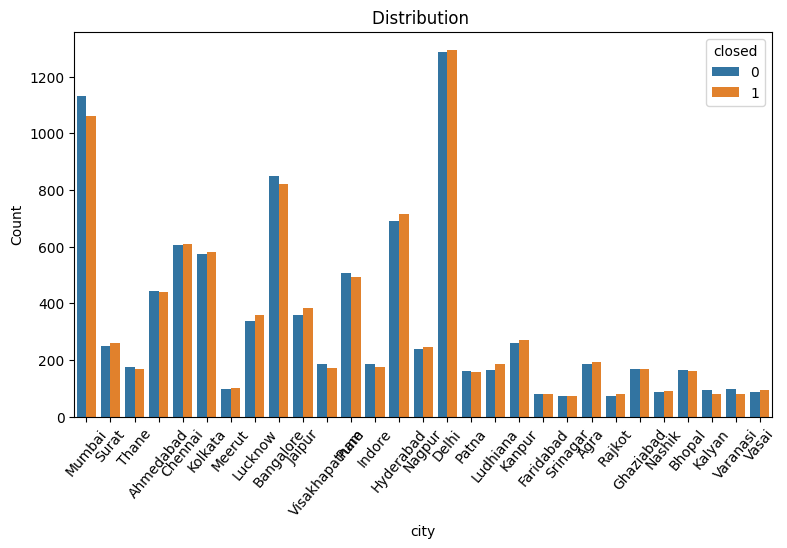

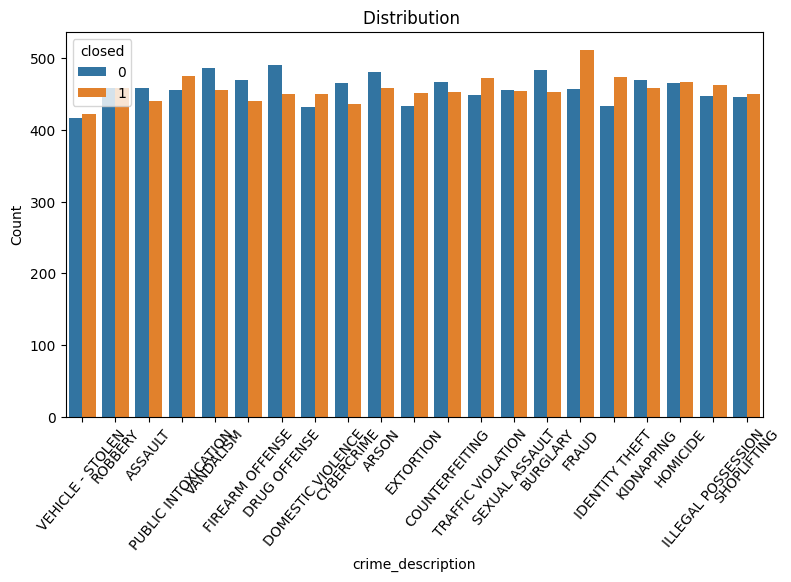

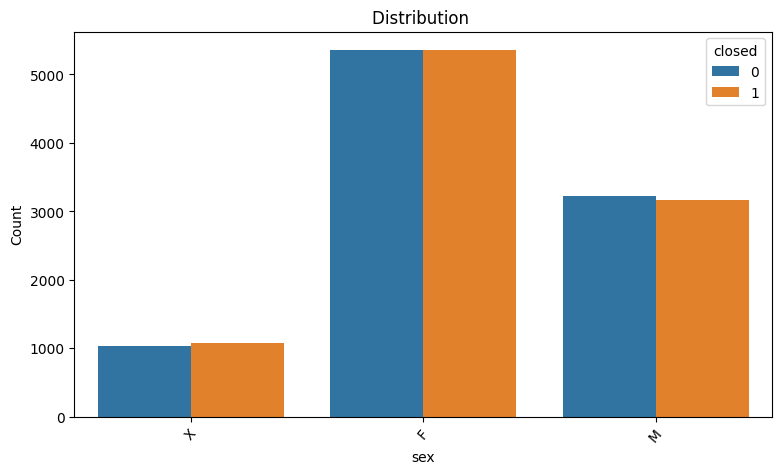

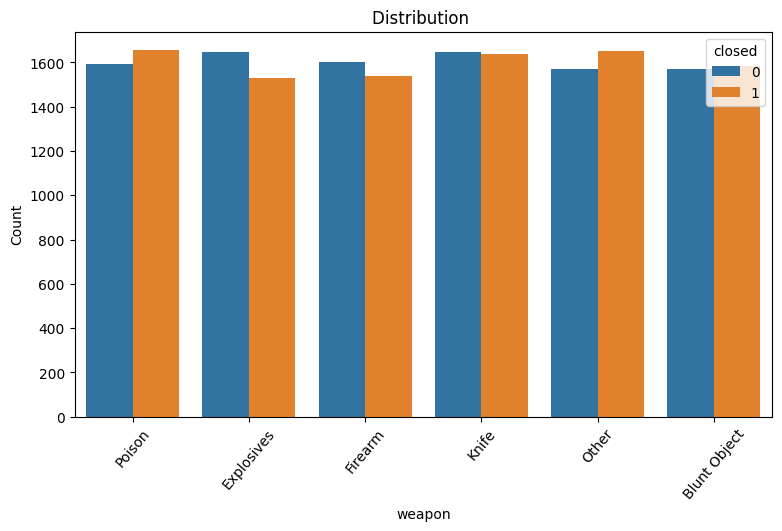

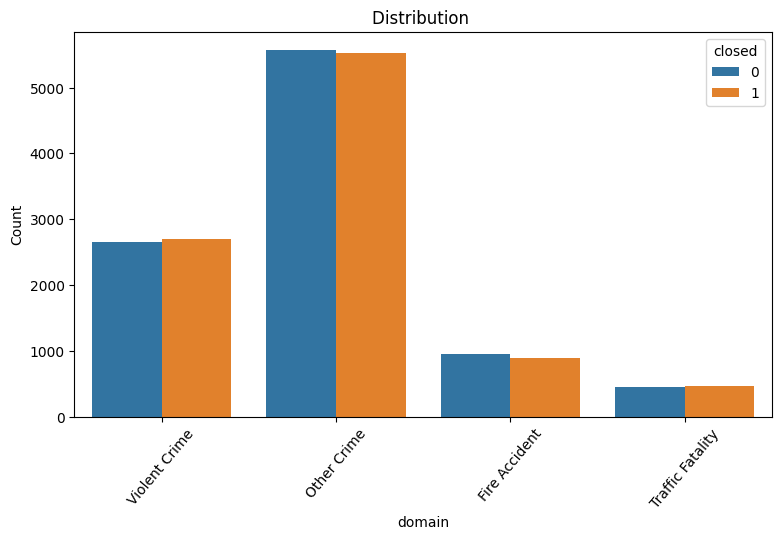

In [9]:
# some graphical analysis
categorical_cols = ['city', 'crime_description', 'sex', 'weapon', 'domain']
for i in categorical_cols:
    plt.figure(figsize=(9, 5))
    sns.countplot(x=i,hue='closed',data=df)
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.title("Distribution ")
    plt.xticks(rotation=50)
    plt.show()

In [7]:
# Doing One Hot encodiing to categorical values (each value into cooresponding True/False)
df = pd.get_dummies(df,columns=['city', 'crime_description', 'weapon', 'domain','sex','age', 'area', 'police_department'],drop_first=True)

In [8]:
for c in ['city', 'crime_description', 'weapon', 'domain', 'sex','age', 'area', 'police_department']:
    df[df.filter(like=c).columns] = df.filter(like=c).astype(float)

In [10]:
# Assigning Data
x_train = df.drop(columns=['closed'])
y_train = df['closed']

In [12]:
X_train = np.array(x_train)
Y_train = np.array(y_train).reshape(-1, 1)

In [13]:
# Normalization
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std[X_std == 0] = 1
X_train = (X_train-X_mean)/X_std

## LR Functions

In [16]:
def sigmoid(z):
    return 1/ (1+np.exp(-np.clip(z,-600,600)))

In [18]:
def compute_cost(X,Y,w,b,l):
    m=X.shape[0];
    y_hat = sigmoid(np.dot(X,w)+b)
    cost = -(1/m)*np.sum(Y*np.log(y_hat + 1e-9) + (1-Y)*np.log(1 - y_hat + 1e-9))
    cost+= (1/(2*m))*np.sum(w**2)
    return cost

In [21]:
def gradient_descent(X,Y,epochs=5000,lr=0.1,l=0.01):
    m,n = X.shape
    w=np.zeros((n,1))
    b=0
    loss_history=[]

    for i in range(epochs):
        y_hat = sigmoid(np.dot(X, w) + b)
        dw = (1/m)*np.dot(X.T,(y_hat-Y)) + (l*w)
        db = np.mean(y_hat-Y)
        w = w - lr*dw
        b = b - lr*db

        if i % 500 == 0:          #250
            cost = compute_cost(X, Y, w, b, l)
            loss_history.append(cost)    #appending this for graph
            print(f"Epoch {i} :  Loss = {cost:.5f}")
    
    plt.figure(figsize=(9,5))
    plt.plot(loss_history)
    plt.grid(True)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("LOSS vs Epochs (Training)")
    plt.show()

    return w, b

## Training Model

Epoch 0 :  Loss = 0.69215
Epoch 500 :  Loss = 0.67237
Epoch 1000 :  Loss = 0.67235
Epoch 1500 :  Loss = 0.67235
Epoch 2000 :  Loss = 0.67234
Epoch 2500 :  Loss = 0.67234
Epoch 3000 :  Loss = 0.67234
Epoch 3500 :  Loss = 0.67234
Epoch 4000 :  Loss = 0.67234
Epoch 4500 :  Loss = 0.67234


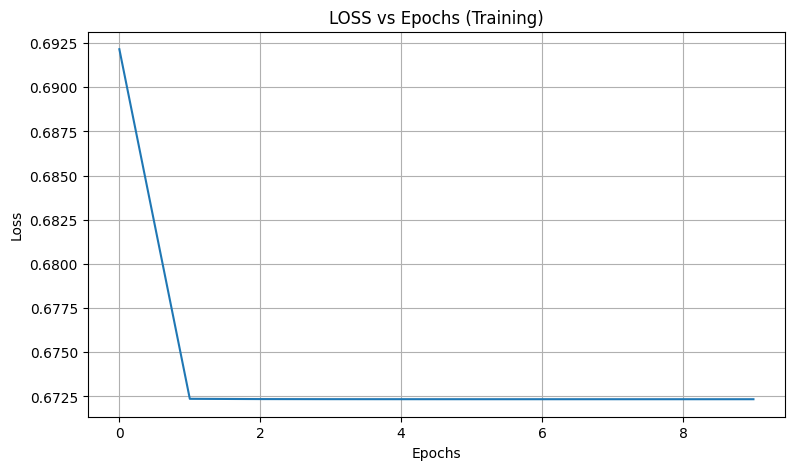

In [22]:
w_final, b_final = gradient_descent(X_train, Y_train)

In [25]:
def accuracy(Y, Y_pred):
    Y_binary = np.where(Y_pred >= 0.5, 1, 0)
    return (np.mean(Y_binary == Y) * 100)

Y_train_pred = sigmoid(np.dot(X_train, w_final) + b_final)
print(f"Training Accuracy: {accuracy(Y_train, Y_train_pred):.5f}")

Training Accuracy: 57.77697


## Testing Model

In [28]:
# Applying same process as training data
df_test = pd.read_csv("crime_test.csv")
df_test = df_test.dropna()

In [29]:
df_test['closed'] = df_test['closed'].map({'Yes': 1, 'No': 0})
df_test = df_test.drop(['Unnamed: 0', 'Num', 'case_filed'], axis=1)
df_test = pd.get_dummies(df_test,columns=['city', 'crime_description', 'weapon', 'domain','sex','age', 'area', 'police_department'],drop_first=True)

In [30]:
for c in ['city', 'crime_description', 'weapon', 'domain', 'sex','age', 'area', 'police_department']:
    df_test[df_test.filter(like=c).columns] = df_test.filter(like=c).astype(float)
df_test = df_test.reindex(columns=df.columns, fill_value=0)

In [32]:
x_test = df_test.drop(columns=['closed'])
y_test = df_test['closed']

In [33]:
X_test = np.array(x_test)
Y_test = np.array(y_test).reshape(-1, 1)

In [36]:
# Normalizing test data -
X_test = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)

In [37]:
Y_test_pred = sigmoid(np.dot(X_test, w_final) + b_final)

In [38]:
print(f"Test Accuracy: {accuracy(Y_test, Y_test_pred):.5f}")

Test Accuracy: 50.17523
